## Генерация выборки

In [209]:
import numpy as np
np.random.seed(42)
N = 25
sample = np.random.exponential(scale=1, size=N)
sample

array([0.46926809, 3.01012143, 1.31674569, 0.91294255, 0.16962487,
       0.16959629, 0.05983877, 2.01123086, 0.91908215, 1.23125006,
       0.02079931, 3.50355748, 1.78642954, 0.23868763, 0.20067899,
       0.20261142, 0.36275373, 0.74392783, 0.56553707, 0.34422299,
       0.94637087, 0.15023453, 0.34551551, 0.45627722, 0.60893469])


## a) Определить по выборке моду, медиану, размах, оценку коэффициента асимметрии

In [54]:
from scipy.stats import skew, mode

moda = np.float64(mode(sample)[0])
median = np.median(sample)
Range = np.max(sample) - np.min(sample)
skewness = skew(sample, bias=False)
print(f"Мода: {moda}", f"Медиана: {median}", f"Размах: {Range}", f"Оценка коэффициента асимметрии: {skewness}", sep='\n')

Мода: 0.020799307999138622
Медиана: 0.4692680899768591
Размах: 3.4827581671591736
Оценка коэффициента асимметрии: 1.8103029679482718


## b) Построить эмпирическую функцию распределения, гистограмму и boxplot

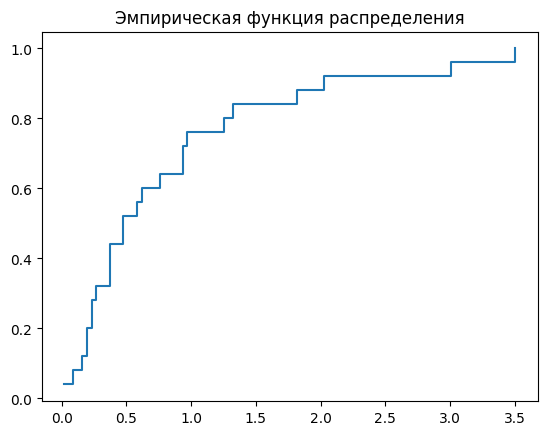

In [23]:
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(sample)
x_ecdf = np.linspace(min(sample), max(sample), 100)
y_ecdf = ecdf(x_ecdf)

plt.step(x_ecdf, y_ecdf, where='post')
plt.title('Эмпирическая функция распределения')
plt.show()

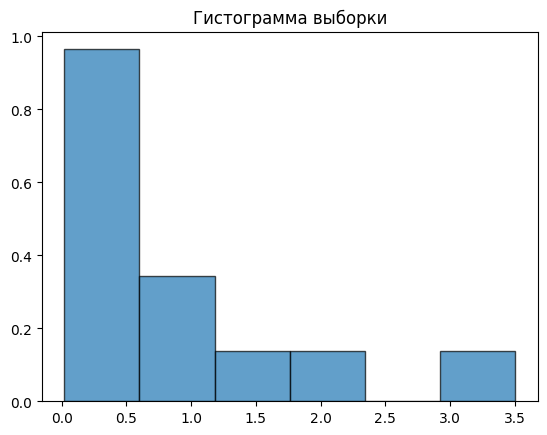

In [90]:
plt.hist(sample, bins=(1 + int(np.ceil(np.log2(N)))), density=True, alpha=0.7, edgecolor='black')
plt.title('Гистограмма выборки')
plt.show()

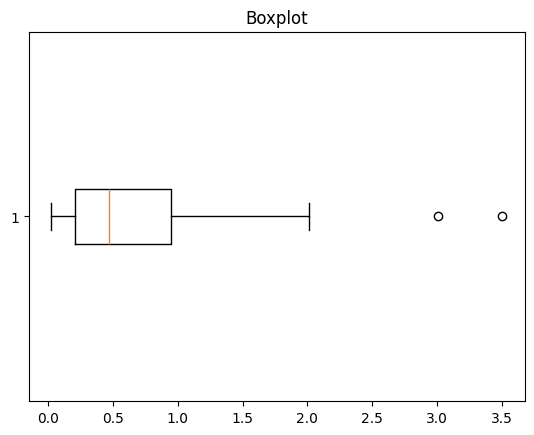

In [55]:
plt.boxplot(sample, vert=False)
plt.title('Boxplot')
plt.show()

## c) Сравнить оценку плотности распределения среднего арифмитического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности

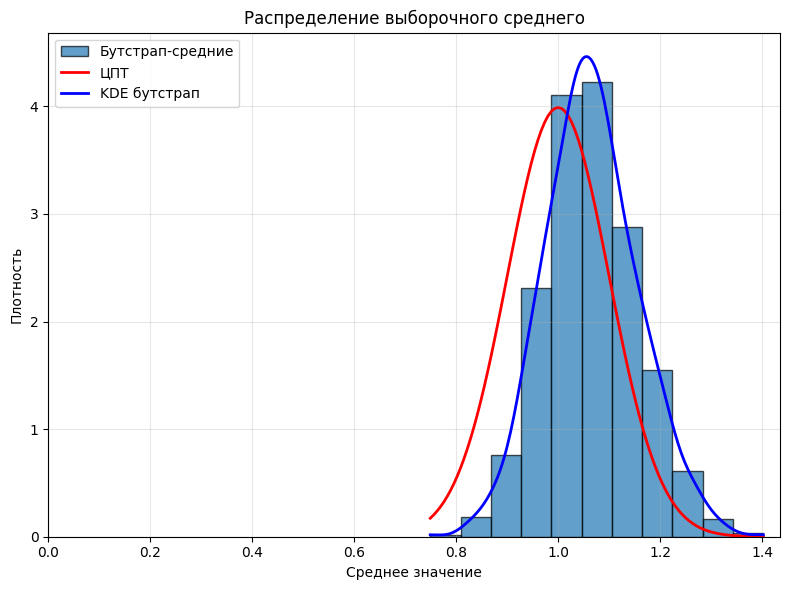

In [177]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

bootstrap_means = []
B = 1000 

for i in range(B):
    bootstrap_sample = np.random.choice(sample, size=N, replace=True)
    bootstrap_means.append(np.mean(bootstrap_sample))

bootstrap_means = np.array(bootstrap_means)


mu_theor = 1
sigma_theor = np.sqrt(1 / N)


fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(bootstrap_means, bins=(1 + int(np.ceil(np.log2(1000)))), density=True, alpha=0.7, edgecolor='black', label='Бутстрап-средние')

x_norm = np.linspace(min(bootstrap_means), max(bootstrap_means), 100)
y_norm_theor = 1 / (np.sqrt(2 * np.pi) * sigma_theor) * np.exp(-(x_norm - mu_theor) ** 2 / (2 * sigma_theor ** 2))
ax.plot(x_norm, y_norm_theor, 'r-', linewidth=2, label='ЦПТ')

kde_bootstrap = gaussian_kde(bootstrap_means)
x_kde = np.linspace(min(bootstrap_means), max(bootstrap_means), 200)
ax.plot(x_kde, kde_bootstrap(x_kde), 'b-', linewidth=2, label='KDE бутстрап')

ax.set_xlabel('Среднее значение')
ax.set_xlim(0)
ax.set_ylim(0)
ax.set_ylabel('Плотность')
ax.set_title('Распределение выборочного среднего')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятность того, что коэффициент асимметрии будет меньше 1

Оценка вероятности P(коэффициент асимметрии < 1) = 0.0790


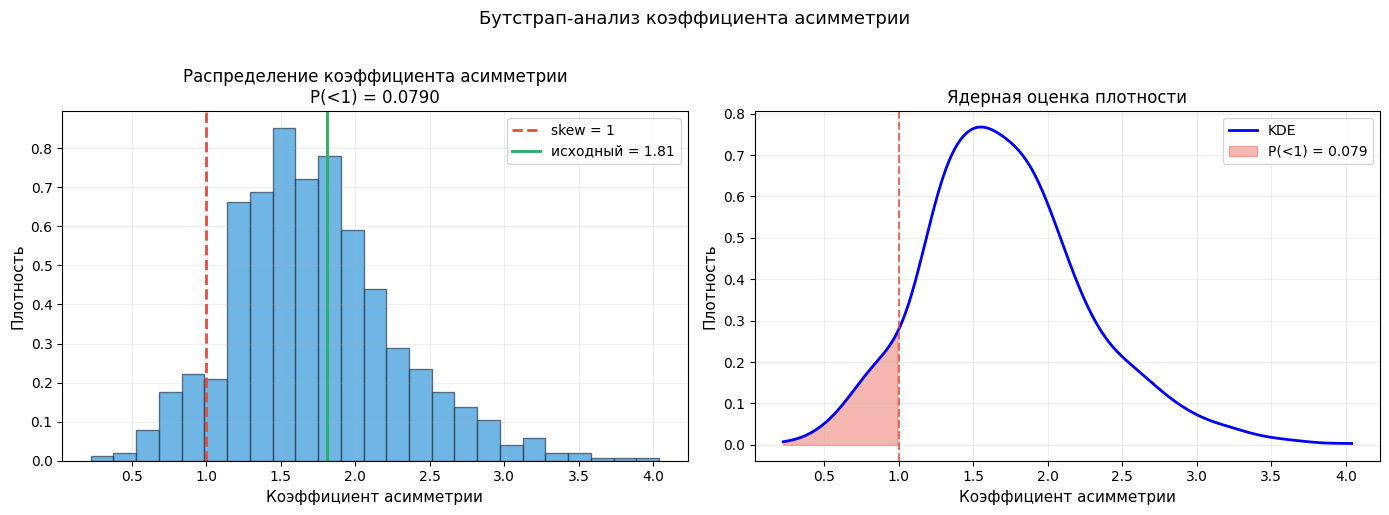

In [311]:
from scipy.stats import skew
orig_skew = skew(sample, bias=False)

n_bootstrap = 1000
boot_skew_vals = []

for i in range(n_bootstrap):
    idx = np.random.randint(0, len(sample), size=len(sample))
    boot = sample[idx]
    boot_skew_vals.append(skew(boot, bias=False))

boot_skew_vals = np.array(boot_skew_vals)

prob_less_than_1 = np.sum(boot_skew_vals < 1) / n_bootstrap
print(f"Оценка вероятности P(коэффициент асимметрии < 1) = {prob_less_than_1:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(boot_skew_vals, bins=25, density=True, 
         alpha=0.7, color='#3498db', edgecolor='#2c3e50', linewidth=1)

ax1.axvline(x=1, color='#e74c3c', linestyle='--', linewidth=2, 
            label=f'skew = 1')
ax1.axvline(x=orig_skew, color='#27ae60', linestyle='-', linewidth=2,
            label=f'исходный = {orig_skew:.2f}')

ax1.set_xlabel('Коэффициент асимметрии', fontsize=11)
ax1.set_ylabel('Плотность', fontsize=11)
ax1.set_title(f'Распределение коэффициента асимметрии\nP(<1) = {prob_less_than_1:.4f}', 
              fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2)

from scipy.stats import gaussian_kde

kde = gaussian_kde(boot_skew_vals)
x_range = np.linspace(boot_skew_vals.min(), boot_skew_vals.max(), 200)
density = kde(x_range)

ax2.plot(x_range, density, 'b-', linewidth=2, label='KDE')

mask = x_range < 1
ax2.fill_between(x_range[mask], density[mask], 
                 alpha=0.4, color='#e74c3c', 
                 label=f'P(<1) = {prob_less_than_1:.3f}')

ax2.axvline(x=1, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.8)

ax2.set_xlabel('Коэффициент асимметрии', fontsize=11)
ax2.set_ylabel('Плотность', fontsize=11)
ax2.set_title('Ядерная оценка плотности', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)

plt.suptitle('Бутстрап-анализ коэффициента асимметрии', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## e) Сравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности

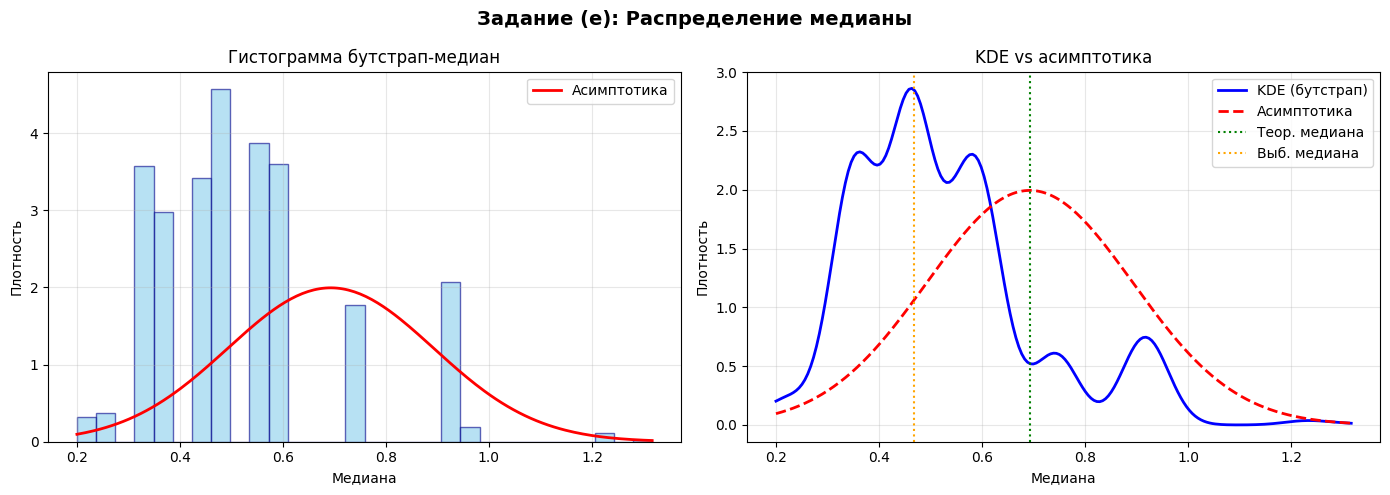

In [304]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

theoretical_median = np.log(2)

f_median = 0.5
asymptotic_se = 1 / (2 * np.sqrt(N) * f_median)

sample_median = np.median(sample)

bootstrap_medians = []
for _ in range(B):
    boot_sample = np.random.choice(sample, size=N, replace=True)
    bootstrap_medians.append(np.median(boot_sample))

bootstrap_medians = np.array(bootstrap_medians)
bootstrap_se = np.std(bootstrap_medians, ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(bootstrap_medians, bins=30, density=True, alpha=0.6,
         color='skyblue', edgecolor='darkblue')
x = np.linspace(bootstrap_medians.min(), bootstrap_medians.max(), 200)
y = norm.pdf(x, loc=theoretical_median, scale=asymptotic_se)
ax1.plot(x, y, 'r-', linewidth=2, label='Асимптотика')
ax1.set_xlabel('Медиана')
ax1.set_ylabel('Плотность')
ax1.set_title('Гистограмма бутстрап-медиан')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
kde = gaussian_kde(bootstrap_medians)
ax2.plot(x, kde(x), 'b-', linewidth=2, label='KDE (бутстрап)')
ax2.plot(x, y, 'r--', linewidth=2, label='Асимптотика')
ax2.axvline(theoretical_median, color='g', linestyle=':', label=f'Теор. медиана')
ax2.axvline(sample_median, color='orange', linestyle=':', label=f'Выб. медиана')
ax2.set_xlabel('Медиана')
ax2.set_ylabel('Плотность')
ax2.set_title('KDE vs асимптотика')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Задание (e): Распределение медианы', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()